Step 1: Exploratory Data Analysis

Building an AI-Based Ensemble System for Corporate Bankruptcy Prediction
A Case Study of US-Listed Companies
This phase looks at the data before any modelling happens. It answers five questions:

1. How much data is there, and is any of it missing?
2. How imbalanced is it (healthy vs bankrupt companies)?
3. Do bankrupt and healthy companies actually look different?
4. Has the bankruptcy rate changed over the years?
5. How do the financial figures relate to one another?
No models are trained here. This is purely getting to know the data.

Data Source:

SETUP

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

df = pd.read_csv("bankruptcy_data.csv")
feature_columns = [c for c in df.columns if c.startswith("X")]

# Plain-English names for the 18 financial figures
FEATURE_LABELS = {
    "X1": "Current Assets", "X2": "Cost of Goods Sold",
    "X3": "Depreciation and Amortization", "X4": "EBITDA",
    "X5": "Inventory", "X6": "Net Income", "X7": "Total Receivables",
    "X8": "Market Value", "X9": "Net Sales", "X10": "Total Assets",
    "X11": "Total Long-Term Debt", "X12": "EBIT", "X13": "Gross Profit",
    "X14": "Total Current Liabilities", "X15": "Retained Earnings",
    "X16": "Total Revenue", "X17": "Total Liabilities",
    "X18": "Total Operating Expenses",
}

df.head()

,company_name,status_label,year,X1,X2,X3,X4,X5,X6,X7,...,X9,X10,X11,X12,X13,X14,X15,X16,X17,X18
0,C_1,alive,1999,511.267,833.107,18.373,89.031,336.018,35.163,128.348,...,1024.333,740.998,180.447,70.658,191.226,163.816,201.026,1024.333,401.483,935.302
1,C_1,alive,2000,485.856,713.811,18.577,64.367,320.590,18.531,115.187,...,874.255,701.854,179.987,45.790,160.444,125.392,204.065,874.255,361.642,809.888
2,C_1,alive,2001,436.656,526.477,22.496,27.207,286.588,-58.939,77.528,...,638.721,710.199,217.699,4.711,112.244,150.464,139.603,638.721,399.964,611.514
3,C_1,alive,2002,396.412,496.747,27.172,30.745,259.954,-12.410,66.322,...,606.337,686.621,164.658,3.573,109.590,203.575,124.106,606.337,391.633,575.592
4,C_1,alive,2003,432.204,523.302,26.680,47.491,247.245,3.504,104.661,...,651.958,709.292,248.666,20.811,128.656,131.261,131.884,651.958,407.608,604.467


1. How much data is there, and is any missing?

Before anything else, confirm the dataset is what the source paper describes,
and check whether any values need cleaning.

In [7]:
print(f"Rows (company-year records): {df.shape[0]:,}")
print(f"Unique companies:            {df['company_name'].nunique():,}")
print(f"Years covered:               {df['year'].min()} to {df['year'].max()}")
print(f"Financial figures per row:   {len(feature_columns)}")
print(f"Missing values anywhere:     {df.isnull().sum().sum()}")

Rows (company-year records): 78,682
Unique companies:            8,971
Years covered:               1999 to 2018
Financial figures per row:   18
Missing values anywhere:     0


How imbalanced is the data?

This is the central difficulty of the whole project. If bankrupt companies are
rare, a model can score highly just by always guessing "healthy" — which is why
accuracy alone is a misleading metric here.

alive   : 73,462 records (93.37%)
failed  :  5,220 records ( 6.63%)


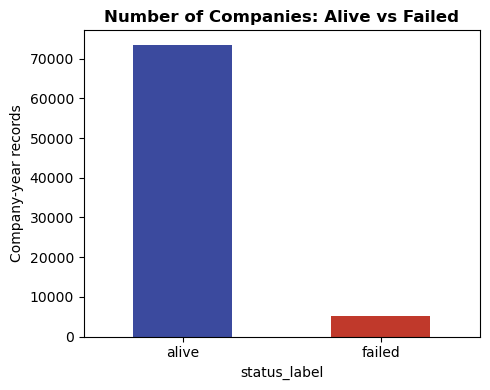

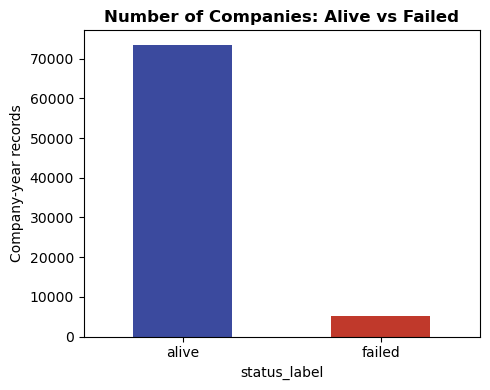

In [8]:
counts = df["status_label"].value_counts()
percentages = df["status_label"].value_counts(normalize=True) * 100
for label in counts.index:
    print(f"{label:8s}: {counts[label]:6,} records ({percentages[label]:5.2f}%)")

plt.figure(figsize=(5, 4))
counts.plot(kind="bar", color=["#3B4A9E", "#C0392B"])
plt.title("Number of Companies: Alive vs Failed", fontweight="bold")
plt.ylabel("Company-year records")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig("chart_class_balance.png", dpi=150)
plt.show()

3. Do bankrupt and healthy companies actually look different?

This is the most important question in the whole EDA. If the two groups looked
identical on these figures, no model could ever separate them, and the project
would have no basis.

In [9]:
print(f"{'Financial figure':32s} {'Alive':>12s} {'Failed':>12s}")
print("-" * 60)
for feat in ["X6", "X15", "X11", "X17", "X10", "X1"]:
    alive_median = df[df["status_label"] == "alive"][feat].median()
    failed_median = df[df["status_label"] == "failed"][feat].median()
    name = f"{feat} - {FEATURE_LABELS[feat]}"
    print(f"{name:32s} {alive_median:12.2f} {failed_median:12.2f}")

Financial figure                        Alive       Failed
------------------------------------------------------------
X6 - Net Income                          2.07        -3.33
X15 - Retained Earnings                 -0.17       -25.51
X11 - Total Long-Term Debt               7.09        18.44
X17 - Total Liabilities                 80.74        97.03
X10 - Total Assets                     215.01       195.14
X1 - Current Assets                    102.92        75.87


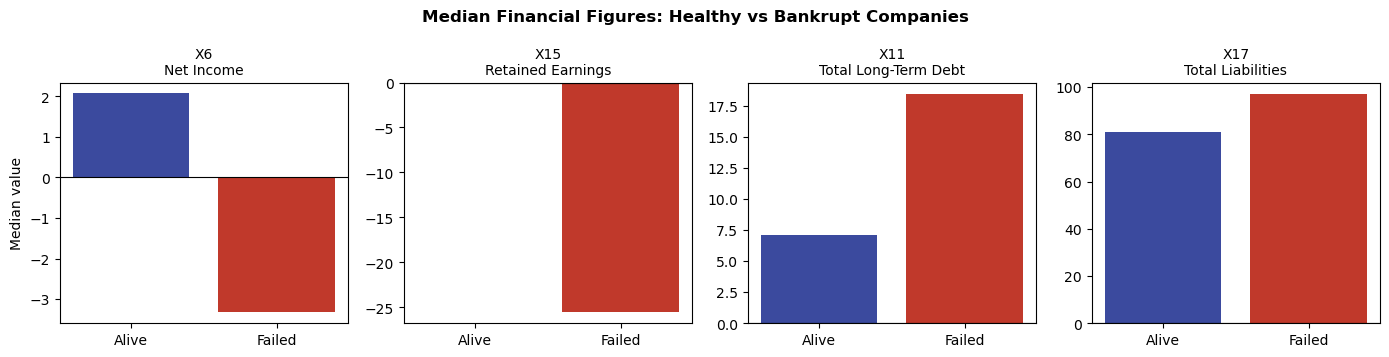

In [10]:
chart_features = ["X6", "X15", "X11", "X17"]
fig, axes = plt.subplots(1, 4, figsize=(14, 3.6))
for ax, feat in zip(axes, chart_features):
    alive_median = df[df["status_label"] == "alive"][feat].median()
    failed_median = df[df["status_label"] == "failed"][feat].median()
    ax.bar(["Alive", "Failed"], [alive_median, failed_median], color=["#3B4A9E", "#C0392B"])
    ax.set_title(f"{feat}\n{FEATURE_LABELS[feat]}", fontsize=10)
    ax.axhline(0, color="black", linewidth=0.8)
    if feat == chart_features[0]:
        ax.set_ylabel("Median value")
plt.suptitle("Median Financial Figures: Healthy vs Bankrupt Companies", fontweight="bold")
plt.tight_layout()
plt.savefig("chart_group_comparison.png", dpi=150)
plt.show()

Finding: bankrupt companies show clearly worse figures — negative median Net
Income, far worse Retained Earnings, and substantially more Long-Term Debt. The
signal the models need does genuinely exist in this data.

4. Has the bankruptcy rate changed over the years?

This matters because the data is split by year for training and testing. If the
failure rate is not stable across those periods, the training years and the test
years are not equally difficult.

In [11]:
for name, first_year, last_year in [("Training", 1999, 2011),
                                     ("Validation", 2012, 2014),
                                     ("Test", 2015, 2018)]:
    subset = df[(df["year"] >= first_year) & (df["year"] <= last_year)]
    rate = (subset["status_label"] == "failed").mean() * 100
    print(f"{name:11s} ({first_year}-{last_year}): {len(subset):6,} records, {rate:5.2f}% failed")

Training    (1999-2011): 55,927 records,  7.94% failed
Validation  (2012-2014): 10,473 records,  4.69% failed
Test        (2015-2018): 12,282 records,  2.34% failed


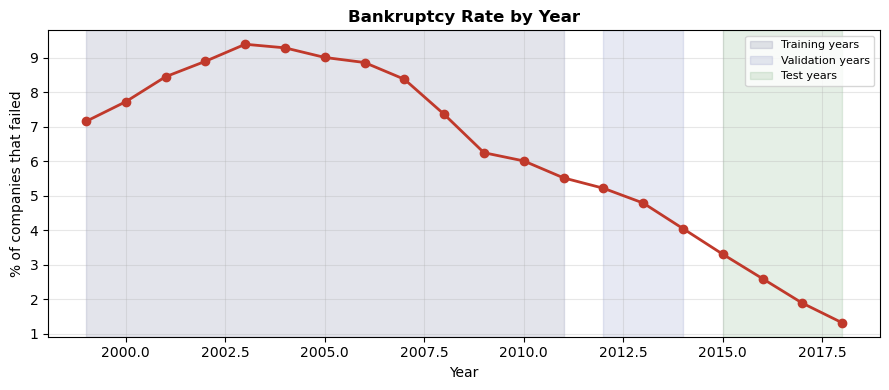

In [12]:
plt.figure(figsize=(9, 4))
yearly_rate = df.groupby("year")["status_label"].apply(lambda s: (s == "failed").mean() * 100)
plt.plot(yearly_rate.index, yearly_rate.values, marker="o", color="#C0392B", linewidth=2)
plt.axvspan(1999, 2011, alpha=0.12, color="#1E2761", label="Training years")
plt.axvspan(2012, 2014, alpha=0.12, color="#3B4A9E", label="Validation years")
plt.axvspan(2015, 2018, alpha=0.12, color="#2E7D32", label="Test years")
plt.title("Bankruptcy Rate by Year", fontweight="bold")
plt.ylabel("% of companies that failed")
plt.xlabel("Year")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("chart_bankruptcy_rate_over_time.png", dpi=150)
plt.show()

Important finding:** the failure rate falls steadily, from roughly 9% in the
early training years to about 2.3% in the test years. The test set is therefore
harder and more imbalanced than the data the models learn from, which means the
reported test results are a **conservative** estimate rather than a flattering one.

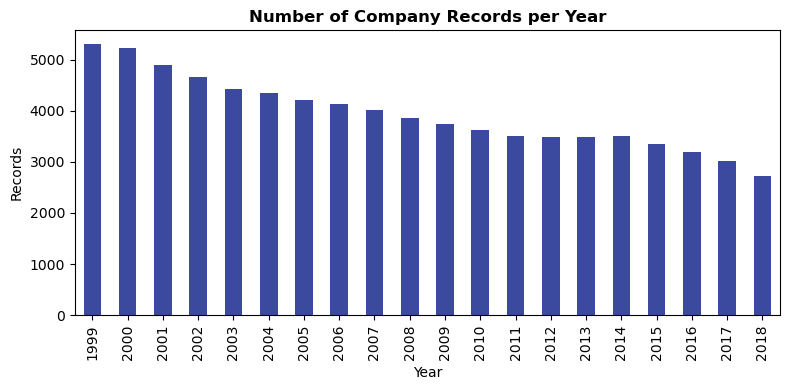

In [13]:
plt.figure(figsize=(8, 4))
df["year"].value_counts().sort_index().plot(kind="bar", color="#3B4A9E")
plt.title("Number of Company Records per Year", fontweight="bold")
plt.ylabel("Records")
plt.xlabel("Year")
plt.tight_layout()
plt.savefig("chart_records_per_year.png", dpi=150)
plt.show()

5. How do the financial figures relate to one another?

A heatmap shows which figures move together. Values near 1 (dark red) mean two
figures rise and fall together; near 0 (pale) means they are unrelated. Strongly
related figures carry overlapping information, which is part of why the feature
selection step in Step 2 is worthwhile.

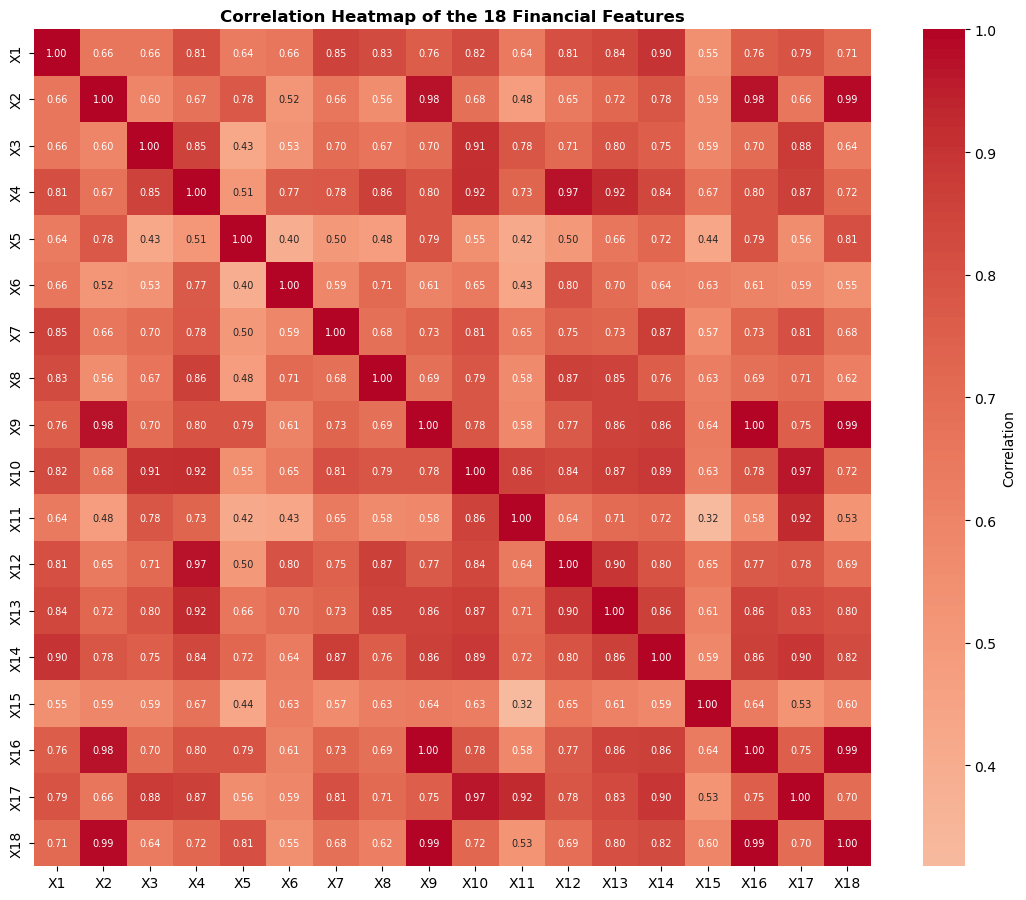

In [14]:
correlation_matrix = df[feature_columns].corr()

plt.figure(figsize=(11, 9))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap="coolwarm",
            center=0, square=True, cbar_kws={"label": "Correlation"},
            annot_kws={"size": 7})
plt.title("Correlation Heatmap of the 18 Financial Features", fontweight="bold")
plt.tight_layout()
plt.savefig("chart_correlation_heatmap.png", dpi=150)
plt.show()

In [16]:
#Report the most strongly related pairs
pairs = correlation_matrix.abs().unstack().sort_values(ascending=False)
pairs = pairs[pairs < 0.999]          # drop each feature paired with itself
seen, top_pairs = set(), []
for (a, b), value in pairs.items():
    if (b, a) not in seen:
        seen.add((a, b))
        top_pairs.append((a, b, value))
    if len(top_pairs) == 3:
        break

print("Most strongly related pairs of figures:")
for a, b, value in top_pairs:
    print(f"  {a} & {b}  ({FEATURE_LABELS[a]} / {FEATURE_LABELS[b]}): {value:.2f}")

Most strongly related pairs of figures:
  X18 & X16  (Total Operating Expenses / Total Revenue): 0.99
  X18 & X9  (Total Operating Expenses / Net Sales): 0.99
  X2 & X18  (Cost of Goods Sold / Total Operating Expenses): 0.99


Finding: several figures are almost perfectly correlated (0.99), meaning they
carry nearly identical information. This directly justifies reducing from 18
features to 12 during Step 2.